✅ Loaded Logs: (142, 6)
✅ Loaded Dataset: (100000, 9)

📊 ===== FINAL METRICS =====
Total Queries: 142
Evaluated Queries: 41
Accuracy: 31.71 %
Mean Error: 12406.178906616797
Median Latency: 53.212999999999994

📂 ===== TYPE PERFORMANCE =====
Type
continuous     72.727273
correlation    50.000000
count          18.181818
percentage     11.764706
Name: Correct, dtype: float64

❌ Failures: 28
                                                Query     True_Value  \
3   4. Percentage of heart disease patients among ...       4.383329   
6   7. Count diabetic patients with BMI greater th...    8500.000000   
11   12. Percentage of diabetic patients under age 40       1.126761   
16      17. Count of female diabetic patients over 50    4461.000000   
23  24. Percentage of diabetic patients with hyper...      17.145594   
27  28. Count of patients with both diabetes and h...  100000.000000   
29  30. Percentage of male patients with hypertension      15.906326   
40       41. Percentage of female

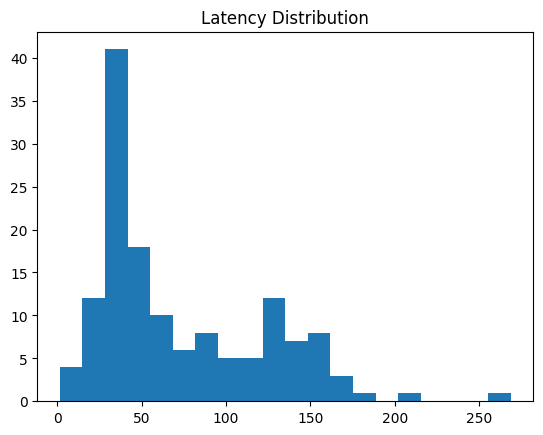

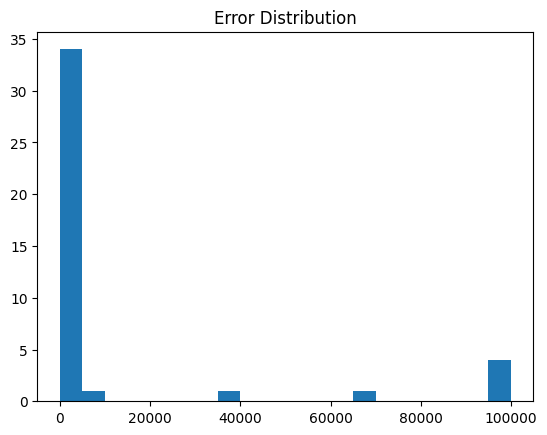

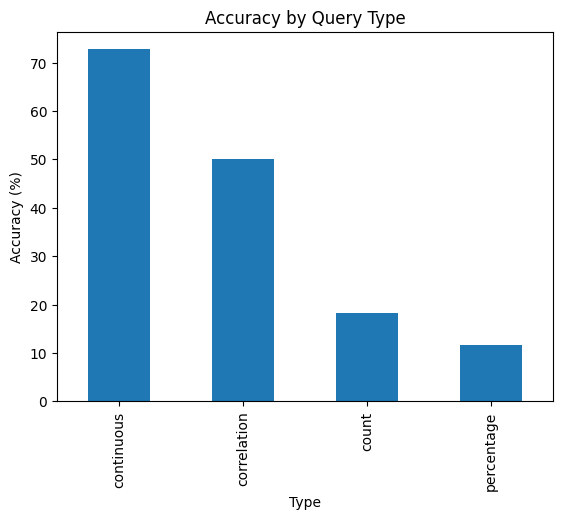


💾 Saved: final_evaluated_results.csv

✅ FINAL NOTEBOOK COMPLETE


In [ ]:
# =========================================================
# CLINICAL AI SYSTEM - FINAL EVALUATION NOTEBOOK
# =========================================================

# =========================
# 1. IMPORTS
# =========================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# =========================
# 2. LOAD DATA
# =========================
LOG_FILE = "/content/persistent_research_audit.csv"
DATASET_FILE = "/content/diabetes_prediction_dataset.csv"

df = pd.read_csv(LOG_FILE)
original_df = pd.read_csv(DATASET_FILE)

print("✅ Loaded Logs:", df.shape)
print("✅ Loaded Dataset:", original_df.shape)

# =========================
# 3. CLEANING
# =========================
df = df.dropna(subset=["Query", "Response"]).reset_index(drop=True)
df["Latency_sec"] = pd.to_numeric(df["Latency_sec"], errors="coerce")

# =========================
# 4. ROBUST NUMBER EXTRACTION
# =========================
def extract_number(text):
    try:
        text = str(text).replace(",", "")
        nums = re.findall(r"-?\d+\.?\d*", text)
        nums = [float(n) for n in nums]

        if len(nums) == 0:
            return np.nan

        # Ignore obvious noise like ages (e.g., 30, 60)
        filtered = [n for n in nums if n < 1000]

        if filtered:
            return filtered[-1]

        return nums[-1]
    except:
        return np.nan

df["Predicted_Value"] = df["Response"].apply(extract_number)

# =========================
# 5. QUERY TYPE DETECTION
# =========================
def detect_type(q):
    q = q.lower()
    if "count" in q:
        return "count"
    elif "percentage" in q or "%" in q:
        return "percentage"
    elif "correlation" in q:
        return "correlation"
    else:
        return "continuous"

df["Type"] = df["Query"].apply(detect_type)

# =========================
# 6. DYNAMIC GROUND TRUTH ENGINE
# =========================
def compute_ground_truth(query):
    try:
        q = query.lower()
        temp_df = original_df.copy()

        # --- AGE FILTER ---
        age_match = re.findall(r'age\s*(above|below|over|under)?\s*(\d+)', q)
        if age_match:
            cond, val = age_match[0]
            val = int(val)
            if cond in ["above", "over"]:
                temp_df = temp_df[temp_df['age'] > val]
            else:
                temp_df = temp_df[temp_df['age'] < val]

        # --- GENDER FILTER ---
        if "female" in q:
            temp_df = temp_df[temp_df['gender'] == "Female"]
        elif "male" in q:
            temp_df = temp_df[temp_df['gender'] == "Male"]

        # --- DIABETES FILTER ---
        if "diabetic" in q:
            temp_df = temp_df[temp_df['diabetes'] == 1]
        elif "non-diabetic" in q:
            temp_df = temp_df[temp_df['diabetes'] == 0]

        # --- HYPERTENSION ---
        if "hypertension" in q:
            temp_df = temp_df[temp_df['hypertension'] == 1]

        # --- SMOKERS ---
        if "smoker" in q:
            temp_df = temp_df[temp_df['smoking_history'] != 'never']

        # =========================
        # OPERATIONS
        # =========================

        if "mean glucose" in q:
            return temp_df['blood_glucose_level'].mean()

        if "mean bmi" in q:
            return temp_df['bmi'].mean()

        if "median age" in q:
            return temp_df['age'].median()

        if "correlation" in q and "hba1c" in q:
            return temp_df['age'].corr(temp_df['HbA1c_level'])

        if "percentage" in q:
            total = len(temp_df)
            if total == 0:
                return np.nan
            return (temp_df['heart_disease'].sum() / total) * 100

        if "count" in q:
            return len(temp_df)

        return np.nan

    except:
        return np.nan

df["True_Value"] = df["Query"].apply(compute_ground_truth)

# =========================
# 7. FILTER VALID DATA
# =========================
df_eval = df[df["True_Value"].notna() & df["Predicted_Value"].notna()].copy()

# =========================
# 8. ERROR CALCULATION
# =========================
df_eval["Error"] = abs(df_eval["True_Value"] - df_eval["Predicted_Value"])
df_eval["Relative_Error"] = df_eval["Error"] / (df_eval["True_Value"] + 1e-6)

# =========================
# 9. TYPE-AWARE ACCURACY
# =========================
df_eval["Correct"] = False

# Continuous
mask = df_eval["Type"] == "continuous"
df_eval.loc[mask, "Correct"] = df_eval.loc[mask, "Relative_Error"] < 0.1

# Percentage
mask = df_eval["Type"] == "percentage"
df_eval.loc[mask, "Correct"] = df_eval.loc[mask, "Relative_Error"] < 0.15

# Correlation
mask = df_eval["Type"] == "correlation"
df_eval.loc[mask, "Correct"] = df_eval.loc[mask, "Error"] < 0.1

# Count
mask = df_eval["Type"] == "count"
df_eval.loc[mask, "Correct"] = df_eval.loc[mask, "Relative_Error"] < 0.2

# =========================
# 10. METRICS
# =========================
print("\n📊 ===== FINAL METRICS =====")
print("Total Queries:", len(df))
print("Evaluated Queries:", len(df_eval))
print("Accuracy:", round(df_eval["Correct"].mean() * 100, 2), "%")
print("Mean Error:", df_eval["Error"].mean())
print("Median Latency:", df["Latency_sec"].median())

# =========================
# 11. CATEGORY PERFORMANCE
# =========================
print("\n📂 ===== TYPE PERFORMANCE =====")
print(df_eval.groupby("Type")["Correct"].mean() * 100)

# =========================
# 12. FAILURE ANALYSIS
# =========================
failures = df_eval[df_eval["Correct"] == False]
print("\n❌ Failures:", len(failures))
print(failures[["Query", "True_Value", "Predicted_Value", "Error"]].head(10))

# =========================
# 13. VISUALS
# =========================
plt.figure()
plt.hist(df["Latency_sec"].dropna(), bins=20)
plt.title("Latency Distribution")
plt.show()

plt.figure()
plt.hist(df_eval["Error"].dropna(), bins=20)
plt.title("Error Distribution")
plt.show()

plt.figure()
(df_eval.groupby("Type")["Correct"].mean() * 100).plot(kind="bar")
plt.title("Accuracy by Query Type")
plt.ylabel("Accuracy (%)")
plt.show()

# =========================
# 14. SAVE RESULTS
# =========================
df_eval.to_csv("final_evaluated_results.csv", index=False)

print("\n💾 Saved: final_evaluated_results.csv")
print("\n✅ FINAL NOTEBOOK COMPLETE")